# Part 1a: Environmental Data and Tidal Resource [20 pts]

Site: **Group 21**. Appendix 1 only lists groups 1-20, so this wraps around to
row 1: **SN167BV** (47°33.7'N, 02°54.9'W).

In [1]:
import sys
from pathlib import Path
sys.path.append("../src")  # lets `import tidaltools` work with plain python, no install needed

import numpy as np
import matplotlib.pyplot as plt

from tidaltools import harmonics

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.3})

# Colours
C_U, C_ENV, C_SP, C_NP, C_REF = "#2a78d6", "#52514e", "#eb6834", "#1baf7a", "#8a8984"

## Input data (Appendix 1, row 1)

| Adm. Ref | Lat | Long | Pk Sp [kt] | Pk Np [kt] | F | M2 [m/s] | S2 [m/s] | K2 [m/s] |
|---|---|---|---|---|---|---|---|---|
| SN167BV | 47 33.7N | 02 54.9W | 5.2 | 3.5 | 0 | 2.2185 | 0.4335 | 0.4437 |

Constituent periods (pre-assignment lecture): $T_{M2} = 12.4206$ h, $T_{S2} = 12.0$ h, $T_{K2} = 11.965$ h.

In [2]:
# ---- Site (Appendix 1, group 21 -> row 1) ----
ADM_REF = "SN167BV"
PK_SP_KT, PK_NP_KT = 5.2, 3.5   # peak spring / neap current [kt]
FZU = 0.0                       # Formzahl number

# Constituents: name -> (amplitude [m/s], period [h])
CONSTITUENTS = {
    "M2": (2.2185, 12.4206),
    "S2": (0.4335, 12.0),
    "K2": (0.4437, 11.965),
}

# ---- Time ----
N_HOURS = 365 * 24
DT = 1.0            # h

print(f"Peak spring current: {PK_SP_KT} kt = {PK_SP_KT * harmonics.KNOT:.3f} m/s")
print(f"Peak neap current  : {PK_NP_KT} kt = {PK_NP_KT * harmonics.KNOT:.3f} m/s")

Peak spring current: 5.2 kt = 2.675 m/s
Peak neap current  : 3.5 kt = 1.801 m/s


## Tidal resource by harmonic superposition

The current velocity is written as a sum of harmonic constituents:

$$U(t) = \sum_{i=1}^{n} U_{A,i}\cos\left(\frac{2\pi t}{T_{A,i}} + \varphi_{A,i}\right)$$

- The Formzahl number is $F = 0$, so the tide is **purely semi-diurnal**. The diurnal constituents (K1, O1) can be neglected, and only M2, S2 and K2 are superposed.
- All phases are set to $\varphi_{A,i} = 0$, so $t = 0$ is a spring tide with all constituents in phase. The phases only shift the series in time; they do not change the annual statistics.
- Positive $U$ is flood and negative $U$ is ebb.

In [3]:
t = np.arange(N_HOURS) * DT          # h, 0 ... 8759
U = harmonics.superpose_constituents(t, CONSTITUENTS)
speed = np.abs(U)
print(f"Generated {len(U)} hourly values ({len(U) / 24:.0f} days)")

Generated 8760 hourly values (365 days)


### Checking the model against the tabulated spring and neap currents

The **spring-neap period** is the beat between M2 and S2:

$$T_{sn} = \left(\frac{1}{T_{S2}} - \frac{1}{T_{M2}}\right)^{-1}$$

K2 has almost the same period as S2, so it beats slowly against S2 (about half a year). This makes the spring tides stronger around the equinoxes.

In [4]:
T_M2, T_S2, T_K2 = (CONSTITUENTS[k][1] for k in ("M2", "S2", "K2"))
A_M2, A_S2, A_K2 = (CONSTITUENTS[k][0] for k in ("M2", "S2", "K2"))

T_sn = harmonics.beat_period(T_M2, T_S2)     # spring-neap period [h]
T_S2K2 = harmonics.beat_period(T_S2, T_K2)   # S2-K2 beat period [h]

daily_max = speed.reshape(365, 24).max(axis=1)

print(f"Spring-neap period (M2-S2 beat) : {T_sn:.1f} h = {T_sn / 24:.2f} days")
print(f"S2-K2 beat period               : {T_S2K2:.0f} h = {T_S2K2 / 24:.1f} days")
print()
print(f"M2 + S2      = {A_M2 + A_S2:.3f} m/s   vs tabulated peak spring {PK_SP_KT * harmonics.KNOT:.3f} m/s")
print(f"M2 - S2      = {A_M2 - A_S2:.3f} m/s   vs tabulated peak neap   {PK_NP_KT * harmonics.KNOT:.3f} m/s")
print(f"M2 + S2 + K2 = {A_M2 + A_S2 + A_K2:.3f} m/s   (theoretical maximum)")
print(f"M2 - S2 - K2 = {A_M2 - A_S2 - A_K2:.3f} m/s   (theoretical minimum neap)")
print()
print(f"Max |U| in hourly series        : {speed.max():.3f} m/s")
print(f"Smallest daily max (neap)       : {daily_max.min():.3f} m/s")
print(f"Mean |U| over the year          : {speed.mean():.3f} m/s")
print(f"RMS U over the year             : {np.sqrt(np.mean(U**2)):.3f} m/s")

Spring-neap period (M2-S2 beat) : 354.4 h = 14.77 days
S2-K2 beat period               : 4102 h = 170.9 days

M2 + S2      = 2.652 m/s   vs tabulated peak spring 2.675 m/s
M2 - S2      = 1.785 m/s   vs tabulated peak neap   1.801 m/s
M2 + S2 + K2 = 3.096 m/s   (theoretical maximum)
M2 - S2 - K2 = 1.341 m/s   (theoretical minimum neap)

Max |U| in hourly series        : 3.096 m/s
Smallest daily max (neap)       : 1.369 m/s
Mean |U| over the year          : 1.439 m/s
RMS U over the year             : 1.629 m/s


### Plot: current velocity over 30 days, showing the neap and spring cycle [20 pts]

The dashed envelope connects the flood and ebb peaks. Spring tides are marked every $T_{sn}$, and neap tides halfway between them.

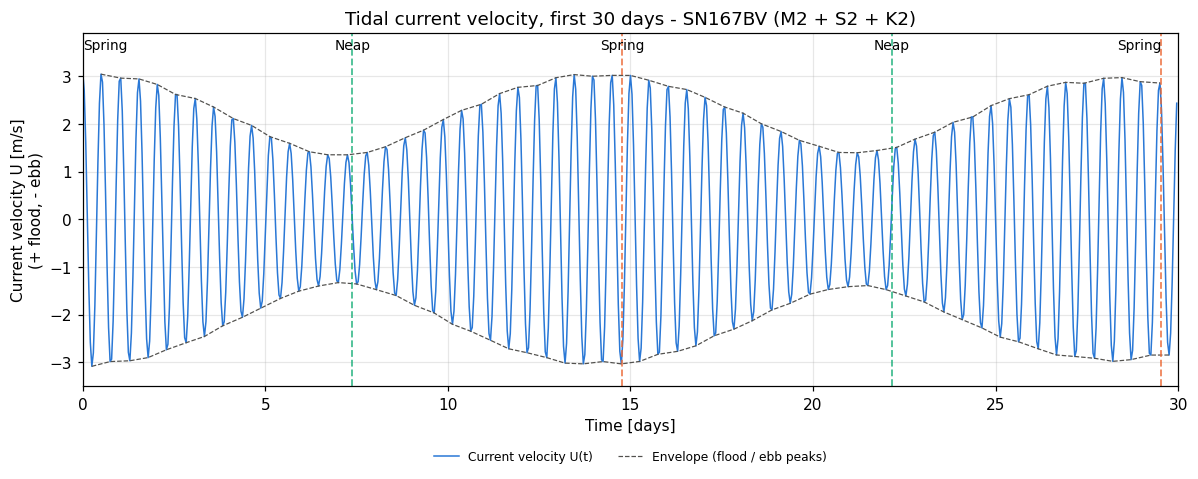

In [5]:
n30 = 30 * 24

# Local peaks of |U| -> envelope
peak_idx = harmonics.local_extrema(speed, kind="max")
pk30 = peak_idx[peak_idx < n30]
pos, neg = pk30[U[pk30] > 0], pk30[U[pk30] < 0]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t[:n30] / 24, U[:n30], color=C_U, lw=1.0, label="Current velocity U(t)")
ax.plot(t[pos] / 24, U[pos], color=C_ENV, lw=0.8, ls="--", label="Envelope (flood / ebb peaks)")
ax.plot(t[neg] / 24, U[neg], color=C_ENV, lw=0.8, ls="--")

# Spring every T_sn, neap halfway in between
for k in range(5):
    tk = k * T_sn / 48   # days
    if tk > 30:
        break
    spring = k % 2 == 0
    ax.axvline(tk, color=C_SP if spring else C_NP, lw=1.2, ls="--", alpha=0.8)
    ax.text(tk, 3.5, "Spring" if spring else "Neap", fontsize=9, va="bottom",
            ha="left" if tk < 1 else ("right" if tk > 29 else "center"))

ax.set_xlim(0, 30)
ax.set_ylim(-3.5, 3.9)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Current velocity U [m/s]\n(+ flood, - ebb)")
ax.set_title(f"Tidal current velocity, first 30 days - {ADM_REF} (M2 + S2 + K2)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(figures_dir / "part1_tidal_velocity_30days.png", dpi=300)
plt.show()

### Supporting plot: daily maximum speed over the whole year

This shows the spring-neap modulation through the year. The strongest springs, at the start and around 6 months, are where S2 and K2 are in phase.

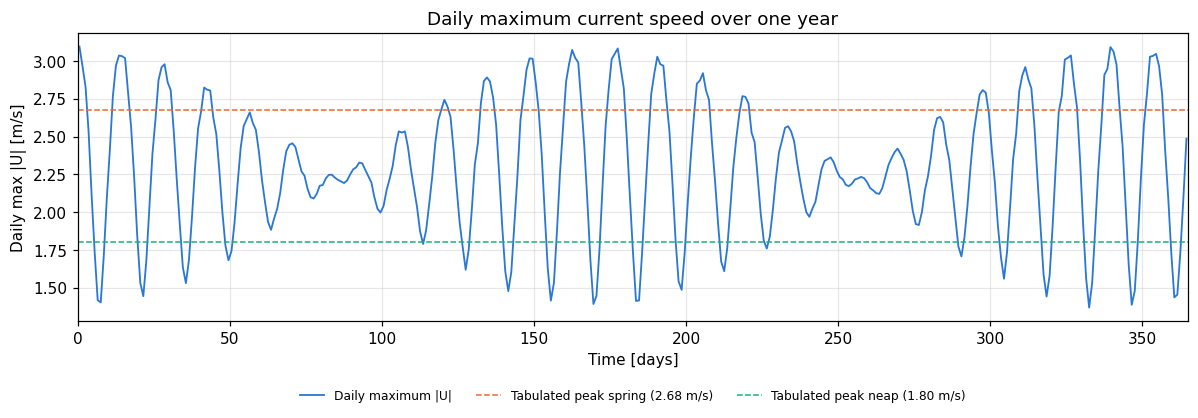

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(365) + 0.5, daily_max, color=C_U, lw=1.2, label="Daily maximum |U|")
ax.axhline(PK_SP_KT * harmonics.KNOT, color=C_SP, lw=1, ls="--", label=f"Tabulated peak spring ({PK_SP_KT * harmonics.KNOT:.2f} m/s)")
ax.axhline(PK_NP_KT * harmonics.KNOT, color=C_NP, lw=1, ls="--", label=f"Tabulated peak neap ({PK_NP_KT * harmonics.KNOT:.2f} m/s)")
ax.set_xlim(0, 365)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Daily max |U| [m/s]")
ax.set_title("Daily maximum current speed over one year")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(figures_dir / "part1_tidal_velocity_daily_max_year.png", dpi=300)
plt.show()

## Discussion

- **Constituents:** Only M2, S2 and K2 are used ($F = 0$). Diurnal (K1, O1), shallow-water (M4) and long-period constituents are neglected. M2 ± S2 reproduces the tabulated spring (2.68 m/s) and neap (1.80 m/s) peak currents well.
- **Phases:** All phases are zero, so $t = 0$ is an equinoctial spring tide. This only shifts the series in time; the annual values do not depend on it.
- **K2 effect:** Because of the S2-K2 beat, the peak spring current varies over the year. At the strongest springs it reaches about 3.1 m/s, slightly above the 3.0 m/s turbine cut-out used in Part 1b.